<a href="https://colab.research.google.com/github/mariocarrasco03/Practicas_redes_neuronales_Mario_Carrasco/blob/main/PRACTICA_04_Clasificacion_con_MLP_Mario_Carrasco_Martinez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="darkorange" size="10"><b>04. Clasificación con MLP</b></font>

Mario Carrasco Martínez

Correo: marioc19@ucm.es

# Ejercicio 01
Usando el generador de pelotas make_blobs crea unos datos con 4 categorías y calcula un MLP para hacer la clasificación.

Ahora tendrás que modificar como ploteas

Y también la última función de activación de la red será una SoftMax

Al igual que con BCE, se prefiere la opción de hacer implicita esas funciones de activación y que sea la función que calcula la función de coste la que las incluya, es decir:

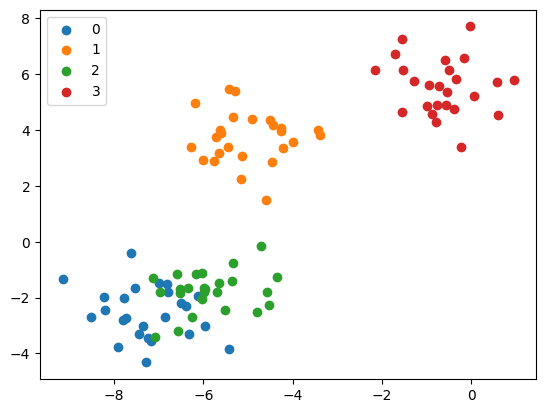

In [ ]:
# Vamos a empezar

from sklearn.datasets import make_blobs
from matplotlib import pyplot as plt


X, y = make_blobs(centers=4, cluster_std=0.8)

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="1")
plt.scatter(X[y == 2, 0], X[y == 2, 1], label="2")
plt.scatter(X[y == 3, 0], X[y == 3, 1], label="3")
plt.legend()
plt.show()

In [ ]:
# Preparamos los datos como antes, pero y no hay que normalizarla
import torch
from torch.utils.data import TensorDataset, DataLoader

# Normalizamos solo X

x_mean, x_std = X.mean(), X.std()
X_norm = (X - x_mean) / x_std

tensor_X = torch.Tensor(X_norm)
tensor_y = torch.Tensor(y)

my_dataset = TensorDataset(tensor_X,tensor_y) # create your datset
my_dataloader = DataLoader(my_dataset) # create your dataloader

In [ ]:
# Vamos a instalar torcheval, es parte de torch y va a facilitar la evaluacion del modelo

!pip install torcheval

In [ ]:


loss_fn = torch.nn.CrossEntropyLoss()

In [ ]:
# Preparamos los datos como antes, pero y no hay que normalizarla
import torch
from torch.utils.data import TensorDataset, DataLoader

# Normalizamos solo X

x_mean, x_std = X.mean(), X.std()
X_norm = (X - x_mean) / x_std

tensor_X = torch.Tensor(X_norm)
tensor_y = torch.tensor(y, dtype=torch.long)
my_dataset = TensorDataset(tensor_X,tensor_y) # create your datset
my_dataloader = DataLoader(my_dataset, batch_size=32, shuffle=True)

In [ ]:

class MLP(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.all_layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_features, 50),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(50, 25),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(25, 4),

        )

    def forward(self, x):
        output = self.all_layers(x)

        return output

In [ ]:
def forward(self, x):
  output = self.all_layers(x)
  return output

In [ ]:
from torcheval.metrics import MulticlassAccuracy, MulticlassConfusionMatrix


torch.manual_seed(1)

model = MLP(num_features=2)


loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

acc = MulticlassAccuracy(num_classes=4)
m_confusion = MulticlassConfusionMatrix(num_classes=4)

In [ ]:
num_epochs = 350

loss_list, acc_list = [], []

for epoch in range(num_epochs):

    model.train()

    epoch_loss = 0.0

    for batch_idx, (features, targets) in enumerate(my_dataloader):
        targets = targets.long()

        output = model(features)
        loss = loss_fn(output, targets)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        acc.update(output, targets)


        epoch_loss += loss.item()

        if not batch_idx % 100:

            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss:.2f}"
                f" | Accuracy: {acc.compute():.2f}"
            )




    loss_media = epoch_loss / len(my_dataloader)


    loss_list.append(loss_media)

    acc_list.append(acc.compute().item())

Epoch: 001/350 | Batch 000/004 | Train Loss: 1.40 | Accuracy: 0.28
Epoch: 002/350 | Batch 000/004 | Train Loss: 1.38 | Accuracy: 0.24
Epoch: 003/350 | Batch 000/004 | Train Loss: 1.34 | Accuracy: 0.26
Epoch: 004/350 | Batch 000/004 | Train Loss: 1.32 | Accuracy: 0.32
Epoch: 005/350 | Batch 000/004 | Train Loss: 1.32 | Accuracy: 0.36
Epoch: 006/350 | Batch 000/004 | Train Loss: 1.32 | Accuracy: 0.38
Epoch: 007/350 | Batch 000/004 | Train Loss: 1.28 | Accuracy: 0.43
Epoch: 008/350 | Batch 000/004 | Train Loss: 1.26 | Accuracy: 0.47
Epoch: 009/350 | Batch 000/004 | Train Loss: 1.27 | Accuracy: 0.50
Epoch: 010/350 | Batch 000/004 | Train Loss: 1.25 | Accuracy: 0.53
Epoch: 011/350 | Batch 000/004 | Train Loss: 1.22 | Accuracy: 0.55
Epoch: 012/350 | Batch 000/004 | Train Loss: 1.17 | Accuracy: 0.57
Epoch: 013/350 | Batch 000/004 | Train Loss: 1.18 | Accuracy: 0.58
Epoch: 014/350 | Batch 000/004 | Train Loss: 1.10 | Accuracy: 0.60
Epoch: 015/350 | Batch 000/004 | Train Loss: 1.09 | Accuracy: 

In [ ]:

model.eval()
yp = model(tensor_X)
yp

tensor([[-16.8989,  -2.7191,  -2.2967,   8.0338],
        [  6.5275,  -6.4594,   2.1090,  -9.4760],
        [-17.5635,  -0.1459,  -3.8054,   7.2008],
        [  5.9324,  -6.0757,   2.1803,  -9.0222],
        [  2.3494,  -4.5956,   2.9471,  -6.1808],
        [  5.0851,  -6.5068,   2.7171,  -7.5289],
        [-15.5372,  -2.7854,  -1.6008,   7.2871],
        [ -6.4663,   4.1566,  -1.8241,  -3.5106],
        [  5.6275,  -5.5786,   2.0983,  -9.1183],
        [ -9.1613,   6.2032,  -3.6147,  -2.7786],
        [-17.9963,  -2.9505,  -2.7364,   8.7652],
        [  1.9727,  -4.8864,   3.2391,  -5.3554],
        [-14.3493,  -0.5634,  -1.8039,   5.5274],
        [-13.9625,  -3.1845,  -0.7118,   6.6073],
        [ -9.2011,   5.8044,  -3.2442,  -2.4287],
        [ -7.3922,   6.1166,  -3.6334,  -4.0867],
        [-14.8780,  -1.9085,  -1.6260,   6.4965],
        [-17.9887,  -5.0914,  -1.8330,   9.7444],
        [ -8.4293,   7.3399,  -4.6818,  -4.2099],
        [ -9.3504,   5.8854,  -3.3623,  -2.4039],


In [ ]:

k = MulticlassConfusionMatrix(num_classes=4)

k.update(yp, tensor_y.long())
print(k.compute())

tensor([[21.,  0.,  4.,  0.],
        [ 0., 25.,  0.,  0.],
        [ 5.,  0., 20.,  0.],
        [ 0.,  0.,  0., 25.]])


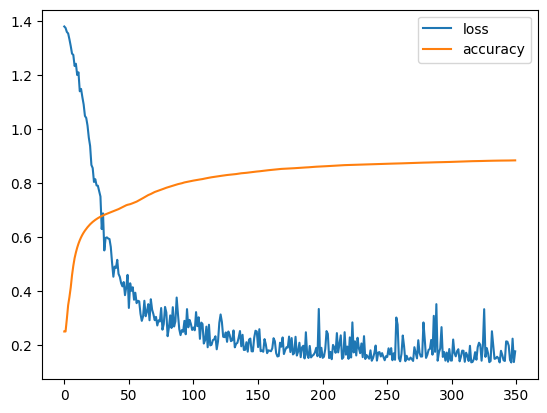

In [ ]:

plt.plot(loss_list)
plt.plot(acc_list)
plt.legend(['loss', 'accuracy'])
plt.show()

pasa lo mismo, no se pone la capa de softmax, va implicita al definir la funcion criterion = nn.CrossEntropyLoss() # Combina softmax y NLLLoss

ahora la matriz de confusion es MulticlassConfusionMatrix(4)



#Ejercicio 02

Haz lo mismo usando make_circles

```python
from sklearn.datasets import make_circles
```


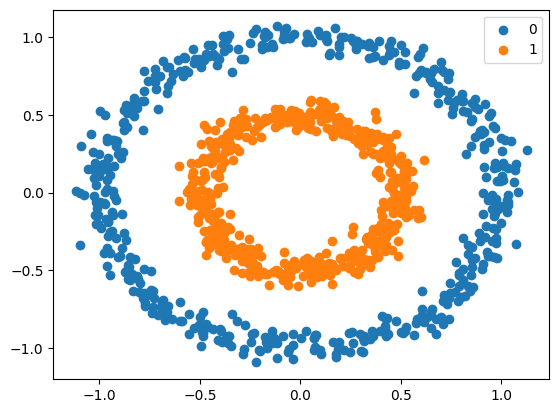

In [ ]:
from sklearn.datasets import make_circles
from matplotlib import pyplot as plt

X, y = make_circles(n_samples=1000, noise=0.05, factor=0.5)
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="1")
plt.legend()

In [ ]:
!pip install torcheval

In [ ]:
# Preparamos los datos como antes, pero y no hay que normalizarla
import torch
from torch.utils.data import TensorDataset, DataLoader

# Normalizamos solo X

x_mean, x_std = X.mean(), X.std()
X_norm = (X - x_mean) / x_std

tensor_X = torch.Tensor(X_norm)
tensor_y = torch.Tensor(y)

my_dataset = TensorDataset(tensor_X,tensor_y) # create your datset
my_dataloader = DataLoader(my_dataset) # create your dataloader

In [ ]:

class MLP(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.all_layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_features, 50),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(50, 25),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(25, 1),


        )

    def forward(self, x):
        output = self.all_layers(x)

        return output.flatten()

In [ ]:
from torcheval.metrics import BinaryAccuracy, BinaryConfusionMatrix

# definimos hiper-parámetros

torch.manual_seed(1)

model = MLP(num_features=2)

loss_fn = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

acc = BinaryAccuracy()
m_confusion = BinaryConfusionMatrix(threshold=0.5)


In [ ]:
num_epochs = 10

loss_list, acc_list = [], []

for epoch in range(num_epochs):

    model.train()
    for batch_idx, (features, targets) in enumerate(my_dataloader):

        # forward
        output = model(features)
        loss = loss_fn(output, targets)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc.update(output, targets)

        loss_list.append(loss.item())
        acc_list.append(acc.compute().item())

        if not batch_idx % 100:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss:.2f}"
                f" | Accuracy: {acc.compute():.2f}"
            )

Epoch: 001/010 | Batch 000/1000 | Train Loss: 0.84 | Accuracy: 1.00
Epoch: 001/010 | Batch 100/1000 | Train Loss: 0.75 | Accuracy: 0.49
Epoch: 001/010 | Batch 200/1000 | Train Loss: 0.57 | Accuracy: 0.48
Epoch: 001/010 | Batch 300/1000 | Train Loss: 0.77 | Accuracy: 0.51
Epoch: 001/010 | Batch 400/1000 | Train Loss: 0.24 | Accuracy: 0.54
Epoch: 001/010 | Batch 500/1000 | Train Loss: 0.79 | Accuracy: 0.59
Epoch: 001/010 | Batch 600/1000 | Train Loss: 0.15 | Accuracy: 0.65
Epoch: 001/010 | Batch 700/1000 | Train Loss: 0.09 | Accuracy: 0.70
Epoch: 001/010 | Batch 800/1000 | Train Loss: 0.08 | Accuracy: 0.74
Epoch: 001/010 | Batch 900/1000 | Train Loss: 0.02 | Accuracy: 0.77
Epoch: 002/010 | Batch 000/1000 | Train Loss: 0.02 | Accuracy: 0.79
Epoch: 002/010 | Batch 100/1000 | Train Loss: 0.23 | Accuracy: 0.81
Epoch: 002/010 | Batch 200/1000 | Train Loss: 0.02 | Accuracy: 0.83
Epoch: 002/010 | Batch 300/1000 | Train Loss: 0.08 | Accuracy: 0.84
Epoch: 002/010 | Batch 400/1000 | Train Loss: 0.

In [ ]:

model.eval()
yp = model(tensor_X)
yp

tensor([-13.6612,  14.8460, -13.0404,  18.1421,  15.0178, -13.1314, -12.5569,
         10.1117, -13.5693,  14.0258, -12.2954,  14.0248, -13.0046, -13.6237,
         14.9365,  13.3693, -11.5387, -13.6693,  15.2549, -15.6091,  13.3905,
         12.2770, -11.9554, -14.7292,  13.0803,   9.7127,  15.6018,  -9.5604,
        -14.9488,  10.4621,  13.1945,  14.6826,  13.5510, -14.2380, -13.8147,
         15.7003,  14.7980, -14.7900,  13.3038,  14.0532,  -9.7584, -10.7149,
        -13.1941,  14.4867,  12.8459,  15.1501, -12.8351, -14.9225, -14.1383,
        -14.4804, -12.4922,   8.2327,  10.8842, -13.5400, -14.0533,  12.4865,
        -12.7324,  15.1723,  14.0760,  14.8926, -13.8137,  16.3935, -15.1449,
        -15.2181,   9.2894,   8.8309, -11.0156,  13.5113, -16.9053,  11.9305,
         13.7821,  14.4682,  15.2117, -13.5612, -13.2935, -14.2442, -13.0878,
          8.4312,  13.5437,  12.0938,  13.5243, -15.5116, -11.7325, -12.4668,
        -13.8209,  12.9434,  12.0391,  10.5167,  13.0267, -11.68

In [ ]:
# Calculamos una matriz de confusion

k = BinaryConfusionMatrix(threshold=0.)
k.update(yp, tensor_y.long())
print(k.compute())

tensor([[500.,   0.],
        [  0., 500.]])


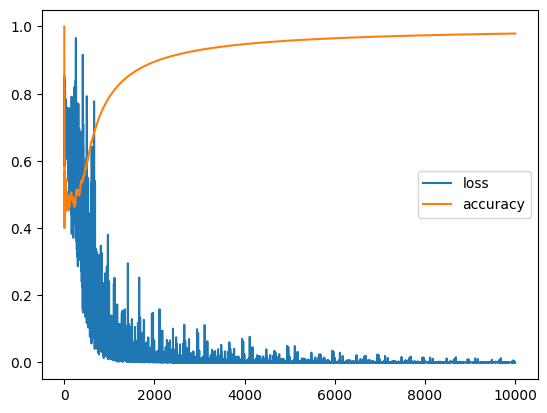

In [ ]:
# Ploteamos

plt.plot(loss_list)
plt.plot(acc_list)
plt.legend(['loss', 'accuracy'])
plt.show()

#Ejercicio 03

Haz lo mismo usando make_moons

```python
from sklearn.datasets import make_moons
```

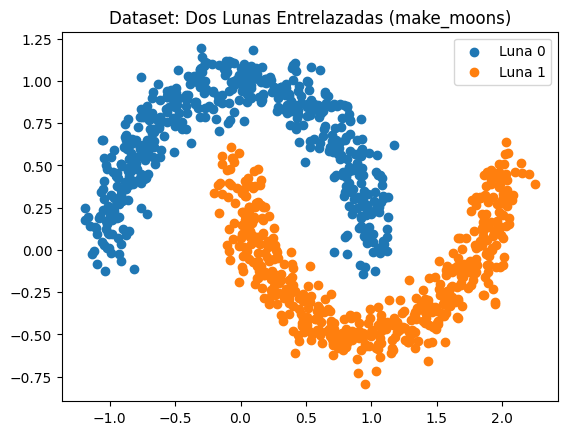

In [ ]:


from sklearn.datasets import make_moons

from matplotlib import pyplot as plt

X, y = make_moons(n_samples=1000, noise=0.1)

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Luna 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Luna 1")
plt.title("Dataset: Dos Lunas Entrelazadas (make_moons)")
plt.legend()
plt.show()

In [ ]:
# Vamos a instalar torcheval, es parte de torch y va a facilitar la evaluacion del modelo

!pip install torcheval

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader


x_mean, x_std = X.mean(), X.std()
X_norm = (X - x_mean) / x_std

tensor_X = torch.Tensor(X_norm)
tensor_y = torch.Tensor(y)

my_dataset = TensorDataset(tensor_X,tensor_y) # create your datset
my_dataloader = DataLoader(my_dataset) # create your dataloader

In [ ]:


class MLP(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.all_layers = torch.nn.Sequential(


            torch.nn.Linear(num_features, 50),
            torch.nn.ReLU(),


            torch.nn.Linear(50, 25),
            torch.nn.ReLU(),


            torch.nn.Linear(25, 1),


        )

    def forward(self, x):
        output = self.all_layers(x)
        return output.flatten()

In [ ]:
from torcheval.metrics import BinaryAccuracy, BinaryConfusionMatrix



torch.manual_seed(1)

model = MLP(num_features=2)


loss_fn = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

acc = BinaryAccuracy()
m_confusion = BinaryConfusionMatrix(threshold=0.5)


In [ ]:
num_epochs = 30


loss_list, acc_list = [], []

for epoch in range(num_epochs):

    model.train()
    for batch_idx, (features, targets) in enumerate(my_dataloader):


        output = model(features)
        loss = loss_fn(output, targets)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc.update(output, targets)


        loss_list.append(loss.item())
        acc_list.append(acc.compute().item())

        if not batch_idx % 100:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss:.2f}"
                f" | Accuracy: {acc.compute():.2f}"
            )


Epoch: 001/030 | Batch 000/1000 | Train Loss: 0.58 | Accuracy: 0.00
Epoch: 001/030 | Batch 100/1000 | Train Loss: 0.34 | Accuracy: 0.71
Epoch: 001/030 | Batch 200/1000 | Train Loss: 0.18 | Accuracy: 0.80
Epoch: 001/030 | Batch 300/1000 | Train Loss: 0.15 | Accuracy: 0.82
Epoch: 001/030 | Batch 400/1000 | Train Loss: 0.05 | Accuracy: 0.84
Epoch: 001/030 | Batch 500/1000 | Train Loss: 0.05 | Accuracy: 0.86
Epoch: 001/030 | Batch 600/1000 | Train Loss: 0.01 | Accuracy: 0.86
Epoch: 001/030 | Batch 700/1000 | Train Loss: 0.07 | Accuracy: 0.87
Epoch: 001/030 | Batch 800/1000 | Train Loss: 0.02 | Accuracy: 0.87
Epoch: 001/030 | Batch 900/1000 | Train Loss: 0.37 | Accuracy: 0.88
Epoch: 002/030 | Batch 000/1000 | Train Loss: 0.02 | Accuracy: 0.89
Epoch: 002/030 | Batch 100/1000 | Train Loss: 0.01 | Accuracy: 0.90
Epoch: 002/030 | Batch 200/1000 | Train Loss: 0.17 | Accuracy: 0.91
Epoch: 002/030 | Batch 300/1000 | Train Loss: 0.02 | Accuracy: 0.91
Epoch: 002/030 | Batch 400/1000 | Train Loss: 0.

In [ ]:
# Vemos que predicciones hace nuestro modelo para nuestro X

model.eval()
yp = model(tensor_X)
yp

tensor([ 24.7556,  30.0683,  21.4826, -18.6909,  25.7355, -20.8837,  25.2333,
        -15.1224,  33.6342, -16.7733, -16.2850, -20.0758,  42.2002,  19.6754,
        -17.9452,  20.7387,  12.1440, -17.5655, -16.8979, -17.4473,  14.9800,
         21.7484, -16.4386, -21.4603, -13.7167,  20.4367, -15.4724,  20.6375,
        -22.7439,  26.3616, -20.6379, -23.5943, -19.4400,  24.0912, -18.8255,
        -15.2887, -24.6109, -16.4821, -16.3605,  29.1916,  21.8536,  23.8117,
         14.9570, -11.9089, -16.1216, -18.8447, -22.9919,  10.7145, -22.1344,
         21.0041,  22.3412, -18.4740, -16.0758,  38.8984,  12.8953, -15.2028,
         17.1580, -15.0938,  21.2944,  20.8939, -23.8290, -25.8024,  20.3395,
        -20.2356,  48.1481,  10.7245,  18.7909,  37.2029, -23.2110,  20.9653,
        -19.7384, -17.8180,  34.6744, -16.8680, -20.3123, -13.4112, -21.5567,
        -17.6428, -18.7283,  29.0856,  22.6381,  24.1430, -20.7241,  53.7982,
        -24.1594, -15.1413, -17.5788, -17.8887,  29.0179, -22.97

In [ ]:

k = BinaryConfusionMatrix(threshold=0.)
k.update(yp, tensor_y.long())
print(k.compute())

tensor([[500.,   0.],
        [  0., 500.]])


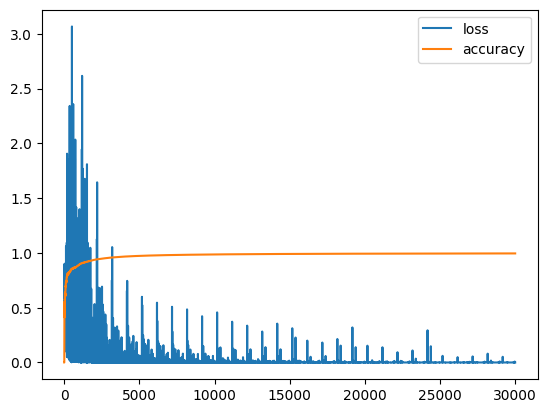

In [ ]:

plt.plot(loss_list)
plt.plot(acc_list)
plt.legend(['loss', 'accuracy'])
plt.show()

#Ejercicio 04. Clasificación binaria con datos de infidelidad

Se analizan unos datos obtenido de Kaggle.com sobre una encuesta de infidelidad: [enlace](https://www.google.com/url?q=https%3A%2F%2Fwww.kaggle.com%2Fdatasets%2Futkarshx27%2Ffairs-extramarital-affairs-data)

Las variables son:

**Criterio**: affairs.

**Predictoras**: gender, age, yearsmarried, children, religiousness, education, occupation, rating.

La variable criterio es de tipo dicotómico **0 = no, 1 = sí** por lo que el análisis convencional nos lleva a un modelo binomial. La precisión (accuracy) en la clasificación obtenida con este modelo es de 0.72

Construye un MLP que supere la precisión del modelo lineal

In [ ]:
%reset -f
import pandas as pd

url = 'https://raw.githubusercontent.com/mcstllns/UNIR2024/main/data-affairs.csv'
data  = pd.read_csv(url)
print(data.keys())
data.head()

Index(['affairs', 'gender', 'age', 'yearsmarried', 'children', 'religiousness',
       'education', 'occupation', 'rating'],
      dtype='object')


,affairs,gender,age,yearsmarried,children,religiousness,education,occupation,rating
0,0,0,37.0,10.00,0,3,18,7,4
1,0,1,27.0,4.00,0,4,14,6,4
2,0,1,32.0,15.00,1,1,12,1,4
3,0,0,57.0,15.00,1,5,18,6,5
4,0,0,22.0,0.75,0,2,17,6,3


In [ ]:
X = data.drop('affairs', axis=1)
y = data['affairs']
y = (y > 0).astype(int)
print(X.columns)
print(X.shape)
print(y.shape)
print(y.unique())

Index(['gender', 'age', 'yearsmarried', 'children', 'religiousness',
       'education', 'occupation', 'rating'],
      dtype='object')
(601, 8)
(601,)
[0 1]


In [ ]:
# Vamos a instalar torcheval, es parte de torch y va a facilitar la evaluacion del modelo

!pip install torcheval

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from torcheval.metrics import BinaryAccuracy, BinaryConfusionMatrix
import matplotlib.pyplot as plt


x_mean, x_std = X.mean(), X.std()
X_norm = (X - x_mean) / x_std

tensor_X = torch.tensor(X_norm.values, dtype=torch.float32)


tensor_y = torch.tensor(y.values, dtype=torch.float32)

my_dataset = TensorDataset(tensor_X, tensor_y)
my_dataloader = DataLoader(my_dataset, batch_size=32, shuffle=True)

In [ ]:

class MLP(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.all_layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_features, 64),
            torch.nn.LeakyReLU(0.01),

            # 2nd hidden layer
            torch.nn.Linear(64, 32),
            torch.nn.LeakyReLU(0.01),

            # output layer
            torch.nn.Linear(32, 1),

        )

    def forward(self, x):
        output = self.all_layers(x)
        return output.flatten()

In [ ]:
from torcheval.metrics import BinaryAccuracy, BinaryConfusionMatrix


torch.manual_seed(1)

model = MLP(num_features=8)


num_ceros = (tensor_y == 0).sum()
num_unos = (tensor_y == 1).sum()


peso = torch.tensor([num_ceros / num_unos], dtype=torch.float32)


loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=peso)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


acc = BinaryAccuracy(threshold=0.0)
m_confusion = BinaryConfusionMatrix(threshold=0.5)

In [ ]:
num_epochs = 300
loss_list, acc_list = [], []

for epoch in range(num_epochs):
    model.train()


    epoch_loss = 0.0

    for batch_idx, (features, targets) in enumerate(my_dataloader):
        output = model(features)
        loss = loss_fn(output, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc.update(output, targets)


        epoch_loss += loss.item()


    loss_media = epoch_loss / len(my_dataloader)
    loss_list.append(loss_media)

    acc_list.append(acc.compute().item())

In [ ]:

model.eval()
yp = model(tensor_X)
yp

tensor([-8.9262e+00, -9.2972e+00, -7.8342e+00, -4.1051e+00, -1.0137e+01,
        -2.8970e+00, -6.3928e+00, -1.4240e+01, -8.4352e-01, -6.3280e+00,
        -2.2970e+00, -2.8534e+00, -1.9895e+00, -6.8772e+00, -6.1318e+00,
        -1.2926e+00, -2.6362e+00, -1.0004e+01, -5.2394e+00, -3.4441e+00,
        -5.2394e+00, -5.2394e+00, -1.3556e+00, -1.6756e+00, -1.3463e+01,
        -2.7613e+00, -8.3708e+00, -4.2182e+00, -4.8985e+00, -1.1232e+00,
        -3.9965e+00, -6.0459e+00, -5.6401e+00, -2.6424e+00, -9.5055e+00,
        -1.0294e+01, -8.9891e+00, -2.9174e+00, -4.5227e+00, -1.2112e+01,
        -1.1142e+00, -4.8528e+00, -8.2629e+00, -2.0974e+00, -4.1210e+00,
        -3.3025e+00, -4.6016e+00, -7.6004e-01, -6.7997e+00, -1.9963e+00,
        -2.6678e+00, -6.2774e+00, -2.3649e+00, -3.0667e+00, -6.0317e+00,
        -4.7270e-01, -8.5007e+00, -1.5637e+00, -9.8957e+00, -5.2484e+00,
        -7.8691e+00, -4.6349e+00, -5.9160e+00, -6.9451e+00, -3.1527e+00,
        -7.6376e+00, -4.1093e+00, -9.0635e+00, -2.8

In [ ]:
# Calculamos una matriz de confusion

k = BinaryConfusionMatrix(threshold=0.)
k.update(yp, tensor_y.long())
print(k.compute())

tensor([[442.,   9.],
        [  5., 145.]])


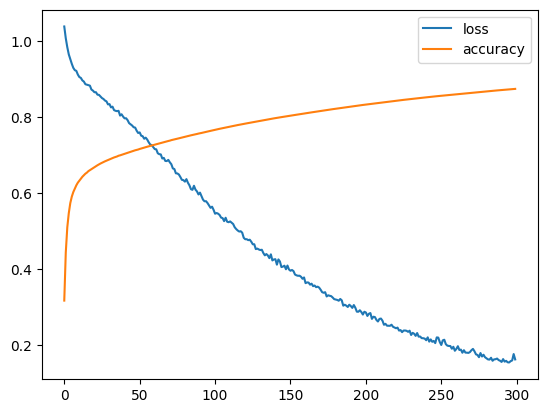

Accuracy: 0.8745


In [ ]:
# Ploteamos

plt.plot(loss_list)
plt.plot(acc_list)
plt.legend(['loss', 'accuracy'])
plt.show()
print(f"Accuracy: {acc_list[-1]:.4f}")